# Fraud Detection - v2 (full dataset, two class-ratio regimes, XGBoost on GPU)

This notebook reuses the **same data-processing pipeline and modelling principles** as the original
`fraud-detection` notebook, with four deliberate differences:

1. **Full dataset.** All ~7.5M rows of `synthetic_fraud_data.csv` are used (v1 worked on a 250k sample).
2. **Two dataset regimes are compared:**
   - **Untouched** - the dataset exactly as provided, then run through the pipeline.
   - **Realistic ratio** - randomly down-sampled with a fixed `random_state` so fraud is ~**0.75%** of rows
     (**99.25 : 0.75**), close to real-world card-fraud prevalence.
3. **Runs on Kaggle GPU.** Meant to be executed on Kaggle with the **T4 x2** accelerator (not locally);
   `XGBClassifier` is configured with `device='cuda'`.
4. **XGBoost only.** The v1 model zoo (RandomForest / AdaBoost / GradientBoosting / DecisionTree / NN)
   is replaced by a single `XGBClassifier`.

> Preprocessing, feature engineering, feature selection, train/test split, oversampling and scaling are
> identical in logic to v1; only the **data scope** and the **model** differ. The pipeline is wrapped in
> functions so the exact same steps run on both dataset regimes.

# Import Packages

In [15]:
%matplotlib inline
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import (classification_report, recall_score, precision_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 500)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ismetsemedov/transactions/synthetic_fraud_data.csv
/kaggle/input/models/thangngocnguyen/fraud-detection-transaction-dataset-xgb/scikitlearn/default/1/fraud-detection-v2.ipynb


# Load the full dataset

The entire file is loaded (no sampling). On Kaggle this fits comfortably in RAM.

In [16]:
# Path discovered via the os.walk cell above -- change DATA_PATH if your dataset slug differs.
DATA_PATH = '/kaggle/input/datasets/ismetsemedov/transactions/synthetic_fraud_data.csv'

# Memory-lean load. The full file is ~7.5M rows with several large string columns; loaded naively
# the frame is ~10 GB and the parser peak is higher, which kills the Kaggle kernel. So we:
#   (a) skip the 5 PII columns the pipeline drops anyway (the biggest strings),
#   (b) read low-cardinality columns as 'category', and (c) downcast the numerics.
# This keeps the frame ~2 GB and lets the read finish comfortably within RAM.
_DROP_AT_LOAD = ['transaction_id', 'customer_id', 'card_number', 'ip_address', 'device_fingerprint']
_CATEGORICAL = ['merchant_category', 'merchant_type', 'merchant', 'currency', 'country',
                'city', 'city_size', 'card_type', 'device', 'channel']
_usecols = [c for c in pd.read_csv(DATA_PATH, nrows=0).columns if c not in _DROP_AT_LOAD]
_dtypes = {c: 'category' for c in _CATEGORICAL}
_dtypes.update({'amount': 'float32', 'distance_from_home': 'int8', 'transaction_hour': 'int8'})

df = pd.read_csv(DATA_PATH, usecols=_usecols, dtype=_dtypes)
print('loaded:', df.shape, '| memory (GB):', round(df.memory_usage(deep=True).sum() / 1e9, 2))
df.head()

loaded: (7483766, 19) | memory (GB): 2.24


,timestamp,merchant_category,merchant_type,merchant,amount,currency,country,city,city_size,card_type,card_present,device,channel,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,2024-09-30 00:00:01.034820+00:00,Restaurant,fast_food,Taco Bell,294.869995,GBP,UK,Unknown City,medium,Platinum Credit,False,iOS App,mobile,0,False,0,False,"{'num_transactions': 1197, 'total_amount': 334...",False
1,2024-09-30 00:00:01.764464+00:00,Entertainment,gaming,Steam,3368.969971,BRL,Brazil,Unknown City,medium,Platinum Credit,False,Edge,web,1,True,0,False,"{'num_transactions': 509, 'total_amount': 2011...",True
2,2024-09-30 00:00:02.273762+00:00,Grocery,physical,Whole Foods,102582.382812,JPY,Japan,Unknown City,medium,Platinum Credit,False,Firefox,web,0,False,0,False,"{'num_transactions': 332, 'total_amount': 3916...",False
3,2024-09-30 00:00:02.297466+00:00,Gas,major,Exxon,630.599976,AUD,Australia,Unknown City,medium,Premium Debit,False,iOS App,mobile,0,False,0,False,"{'num_transactions': 764, 'total_amount': 2201...",False
4,2024-09-30 00:00:02.544063+00:00,Healthcare,medical,Medical Center,724949.250000,NGN,Nigeria,Unknown City,medium,Basic Debit,False,Chrome,web,1,False,0,False,"{'num_transactions': 218, 'total_amount': 4827...",True


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7483766 entries, 0 to 7483765
Data columns (total 19 columns):
 #   Column               Dtype   
---  ------               -----   
 0   timestamp            object  
 1   merchant_category    category
 2   merchant_type        category
 3   merchant             category
 4   amount               float32 
 5   currency             category
 6   country              category
 7   city                 category
 8   city_size            category
 9   card_type            category
 10  card_present         bool    
 11  device               category
 12  channel              category
 13  distance_from_home   int8    
 14  high_risk_merchant   bool    
 15  transaction_hour     int8    
 16  weekend_transaction  bool    
 17  velocity_last_hour   object  
 18  is_fraud             bool    
dtypes: bool(4), category(10), float32(1), int8(2), object(2)
memory usage: 256.9+ MB


In [18]:
df.describe()

,amount,distance_from_home,transaction_hour
count,7.483766e+06,7.483766e+06,7.483766e+06
mean,4.792469e+04,3.220519e-01,1.215467e+01
std,1.745001e+05,4.672628e-01,6.536767e+00
min,1.000000e-02,0.000000e+00,0.000000e+00
25%,3.635300e+02,0.000000e+00,7.000000e+00
50%,1.177450e+03,0.000000e+00,1.200000e+01
75%,2.242953e+04,1.000000e+00,1.800000e+01
max,6.253152e+06,1.000000e+00,2.300000e+01


In [19]:
print(df.shape)

(7483766, 19)


# Two dataset regimes

We build two versions of the data and push **both** through the identical pipeline:

* **Untouched** - the dataset as-is.
* **Realistic** - keep all legitimate transactions and randomly down-sample the fraud class
  (fixed `random_state`) until fraud is ~0.75% of rows, i.e. a 99.25 : 0.75 split that mirrors
  real-world fraud prevalence.

In [20]:
TARGET_FRAUD_RATE = 0.0075   # 99.25% legit : 0.75% fraud

df_untouched = df            # full dataset, exactly as provided

legit = df[df['is_fraud'] == False]
fraud = df[df['is_fraud'] == True]

# keep all legit, down-sample fraud so it is TARGET_FRAUD_RATE of the realistic dataset
n_fraud_keep = int(round(len(legit) * TARGET_FRAUD_RATE / (1 - TARGET_FRAUD_RATE)))
fraud_down = fraud.sample(n=n_fraud_keep, random_state=42)
df_realistic = (pd.concat([legit, fraud_down])
                .sample(frac=1, random_state=42)
                .reset_index(drop=True))

del legit, fraud, fraud_down
gc.collect()

for name, d in [('Untouched', df_untouched), ('Realistic', df_realistic)]:
    vc = d['is_fraud'].value_counts(normalize=True)
    print(f'{name:10s}: {len(d):>10,} rows | '
          f'fraud = {vc.get(True, 0) * 100:6.3f}% | legit = {vc.get(False, 0) * 100:6.3f}%')

Untouched :  7,483,766 rows | fraud = 19.973% | legit = 80.027%
Realistic :  6,034,304 rows | fraud =  0.750% | legit = 99.250%


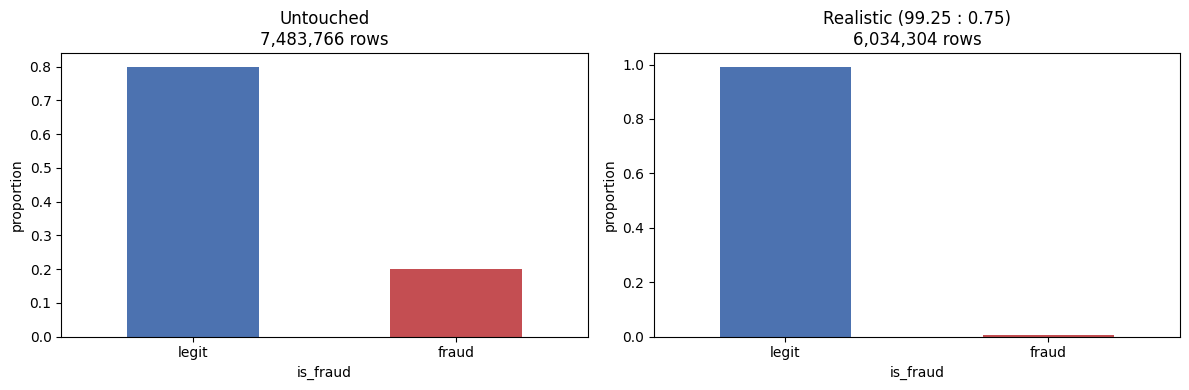

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, d) in zip(axes, [('Untouched', df_untouched),
                                ('Realistic (99.25 : 0.75)', df_realistic)]):
    d['is_fraud'].value_counts(normalize=True).sort_index().plot.bar(ax=ax, color=['#4c72b0', '#c44e52'])
    ax.set_title(f'{name}\n{len(d):,} rows')
    ax.set_xticklabels(['legit', 'fraud'], rotation=0)
    ax.set_ylabel('proportion')
plt.tight_layout()
plt.show()

# Data-processing pipeline

The same logic as v1, wrapped in functions so it can be applied to either dataset regime.

**`preprocess`** - drop PII, cast booleans to int, parse the timestamp, expand the
`velocity_last_hour` dictionary into columns, and extract datetime parts. The dictionary column is
parsed with a **vectorised regex** instead of a per-row `ast.literal_eval` (the per-row version is far
too slow on 7.5M rows; the regex was verified to produce identical values).

In [22]:
# --- vectorised parse of the velocity_last_hour dict-strings (fast on 7.5M rows) ---
_NUM = r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?"
_VEL_PAT = (
    rf"'num_transactions':\s*({_NUM}),\s*'total_amount':\s*({_NUM}),\s*"
    rf"'unique_merchants':\s*({_NUM}),\s*'unique_countries':\s*({_NUM}),\s*"
    rf"'max_single_amount':\s*({_NUM})"
)

def parse_velocity(series):
    vel = series.str.extract(_VEL_PAT)
    out = pd.DataFrame(index=series.index)
    out['num_transactions'] = vel[0].astype(float).fillna(0).astype('int64')
    out['total_amount']      = vel[1].astype(float).fillna(0.0)
    out['unique_merchants']  = vel[2].astype(float).fillna(0).astype('int64')
    out['unique_countries']  = vel[3].astype(float).fillna(0).astype('int64')
    out['max_single_amount'] = vel[4].astype(float).fillna(0.0)
    return out

def preprocess(data):
    data = data.copy()
    # drop PII / identifiers (errors='ignore' since the lean load already skips most of them)
    data = data.drop(['transaction_id', 'customer_id', 'card_number',
                      'ip_address', 'device_fingerprint'], axis=1, errors='ignore')
    # booleans -> int
    for col in data.select_dtypes('bool').columns:
        data[col] = data[col].astype('int')
    # timestamp -> datetime
    data['timestamp'] = pd.to_datetime(data['timestamp'], format='ISO8601')
    # expand velocity_last_hour into numeric columns
    vel = parse_velocity(data['velocity_last_hour'])
    for c in vel.columns:
        data[c] = vel[c].values
    data = data.drop('velocity_last_hour', axis=1)
    # datetime parts (same fields as v1)
    data['year'] = data['timestamp'].dt.year
    data['month'] = data['timestamp'].dt.month
    data['day'] = data['timestamp'].dt.day
    data['hour'] = data['timestamp'].dt.hour
    data['minute'] = data['timestamp'].dt.minute
    data['second'] = data['timestamp'].dt.second
    data['microsecond'] = data['timestamp'].dt.microsecond
    data = data.drop('timestamp', axis=1)
    return data

**`feature_engineer`** - convert local `amount` to USD, add a `is_bank_operating` flag, map
`card_type` to an ordinal scale, collapse `merchant` to its top-20 values, and one-hot encode the
remaining categoricals. One-hot columns use `int8` to keep memory reasonable at full scale.

In [23]:
def feature_engineer(data):
    data = data.copy()
    # local currency -> USD (GBP defaults to 1.28)
    conversion_rates = {'EUR': 1.06, 'CAD': 0.72, 'RUB': 0.01, 'NGN': 0.0006, 'SGD': 0.75,
                        'MXN': 0.049, 'BRL': 0.17, 'AUD': 0.65, 'JPY': 0.0065}
    data['USD_converted_amount'] = data['amount'] * data['currency'].map(conversion_rates).fillna(1.28)
    data = data.drop(['amount', 'currency'], axis=1)
    # bank operating hours flag
    data['is_bank_operating'] = np.where(data['transaction_hour'] < 9, 0,
                                         np.where(data['transaction_hour'] <= 17, 1, 0))
    # ordinal card_type
    data['card_type'] = data['card_type'].map({'Premium Debit': 4, 'Platinum Credit': 3,
                                               'Gold Credit': 2, 'Basic Debit': 1, 'Basic Credit': 0})
    # collapse merchant to top-20 then one-hot
    top_merchants = data['merchant'].value_counts().nlargest(20).index
    data['merchant'] = data['merchant'].astype('object').where(data['merchant'].isin(top_merchants), 'Other')
    data = pd.get_dummies(data, columns=['merchant'], prefix='merchant', dtype='int8')
    # one-hot encode the remaining nominal categoricals
    data = pd.get_dummies(data, dtype='int8')
    return data

**`prepare_train_test`** - select the top-20 features by absolute correlation with `is_fraud`
(same idea as v1, implemented robustly: `is_fraud` is excluded, and constant columns such as `year`
that yield a NaN correlation are dropped automatically), stratified 80/20 split,
`RandomOverSampler` to balance the **training** set, then `MinMaxScaler`.

In [24]:
def prepare_train_test(data_clean, n_features=20, random_state=97):
    # feature selection on a sample keeps corr() off the full 7.5M x ~100 frame (avoids a big spike)
    corr_sample = data_clean.sample(min(500_000, len(data_clean)), random_state=21)
    corr = corr_sample.corr(numeric_only=True)['is_fraud'].drop('is_fraud').abs()
    selected = corr.dropna().sort_values(ascending=False).head(n_features).index.tolist()
    del corr_sample
    gc.collect()

    X, y = data_clean[selected], data_clean['is_fraud']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=random_state)

    # balance only the training set (test set keeps its real ratio for honest evaluation)
    X_train, y_train = RandomOverSampler(random_state=random_state).fit_resample(X_train, y_train)

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, selected

# EDA

Exploratory plots follow the same approach as v1. To keep rendering fast on the full dataset, the
plots are drawn from a 200k random sample of the **untouched** data (after preprocessing); the models
themselves are trained on the full data further down.

In [25]:
# Preprocess only a 200k render-sample for the EDA plots (modelling below uses the full data).
eda_plot = preprocess(df_untouched.sample(min(200000, len(df_untouched)), random_state=21))
print('EDA render sample:', eda_plot.shape)
eda_plot.head()

EDA render sample: (200000, 29)


,merchant_category,merchant_type,merchant,amount,currency,country,city,city_size,card_type,card_present,device,channel,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,is_fraud,num_transactions,total_amount,unique_merchants,unique_countries,max_single_amount,year,month,day,hour,minute,second,microsecond
1858912,Entertainment,streaming,Spotify,169.369995,EUR,Germany,Unknown City,medium,Premium Debit,0,Firefox,web,0,1,17,0,0,27,2.527161e+06,21,6,1.897486e+06,2024,10,7,17,14,22,181495
4000291,Restaurant,premium,Ruth's Chris,823.669983,CAD,Canada,Unknown City,medium,Platinum Credit,0,Chrome,web,0,0,14,0,0,437,1.567628e+07,102,12,1.491427e+06,2024,10,16,14,20,16,817017
7401742,Entertainment,streaming,Spotify,21948.660156,RUB,Russia,Unknown City,medium,Gold Credit,0,Safari,web,0,1,16,0,0,6,3.404636e+05,6,5,2.592671e+05,2024,10,30,16,30,10,768556
793857,Healthcare,medical,Lab Corp,1602.459961,NGN,Nigeria,Unknown City,medium,Premium Debit,0,Edge,web,1,0,8,0,1,944,2.583898e+07,105,12,1.871011e+06,2024,10,3,8,21,32,928515
2160861,Restaurant,casual,Applebee's,89.800003,SGD,Singapore,Unknown City,medium,Basic Debit,0,Firefox,web,0,0,22,0,0,148,2.367273e+06,71,11,6.834904e+05,2024,10,8,22,41,26,566924


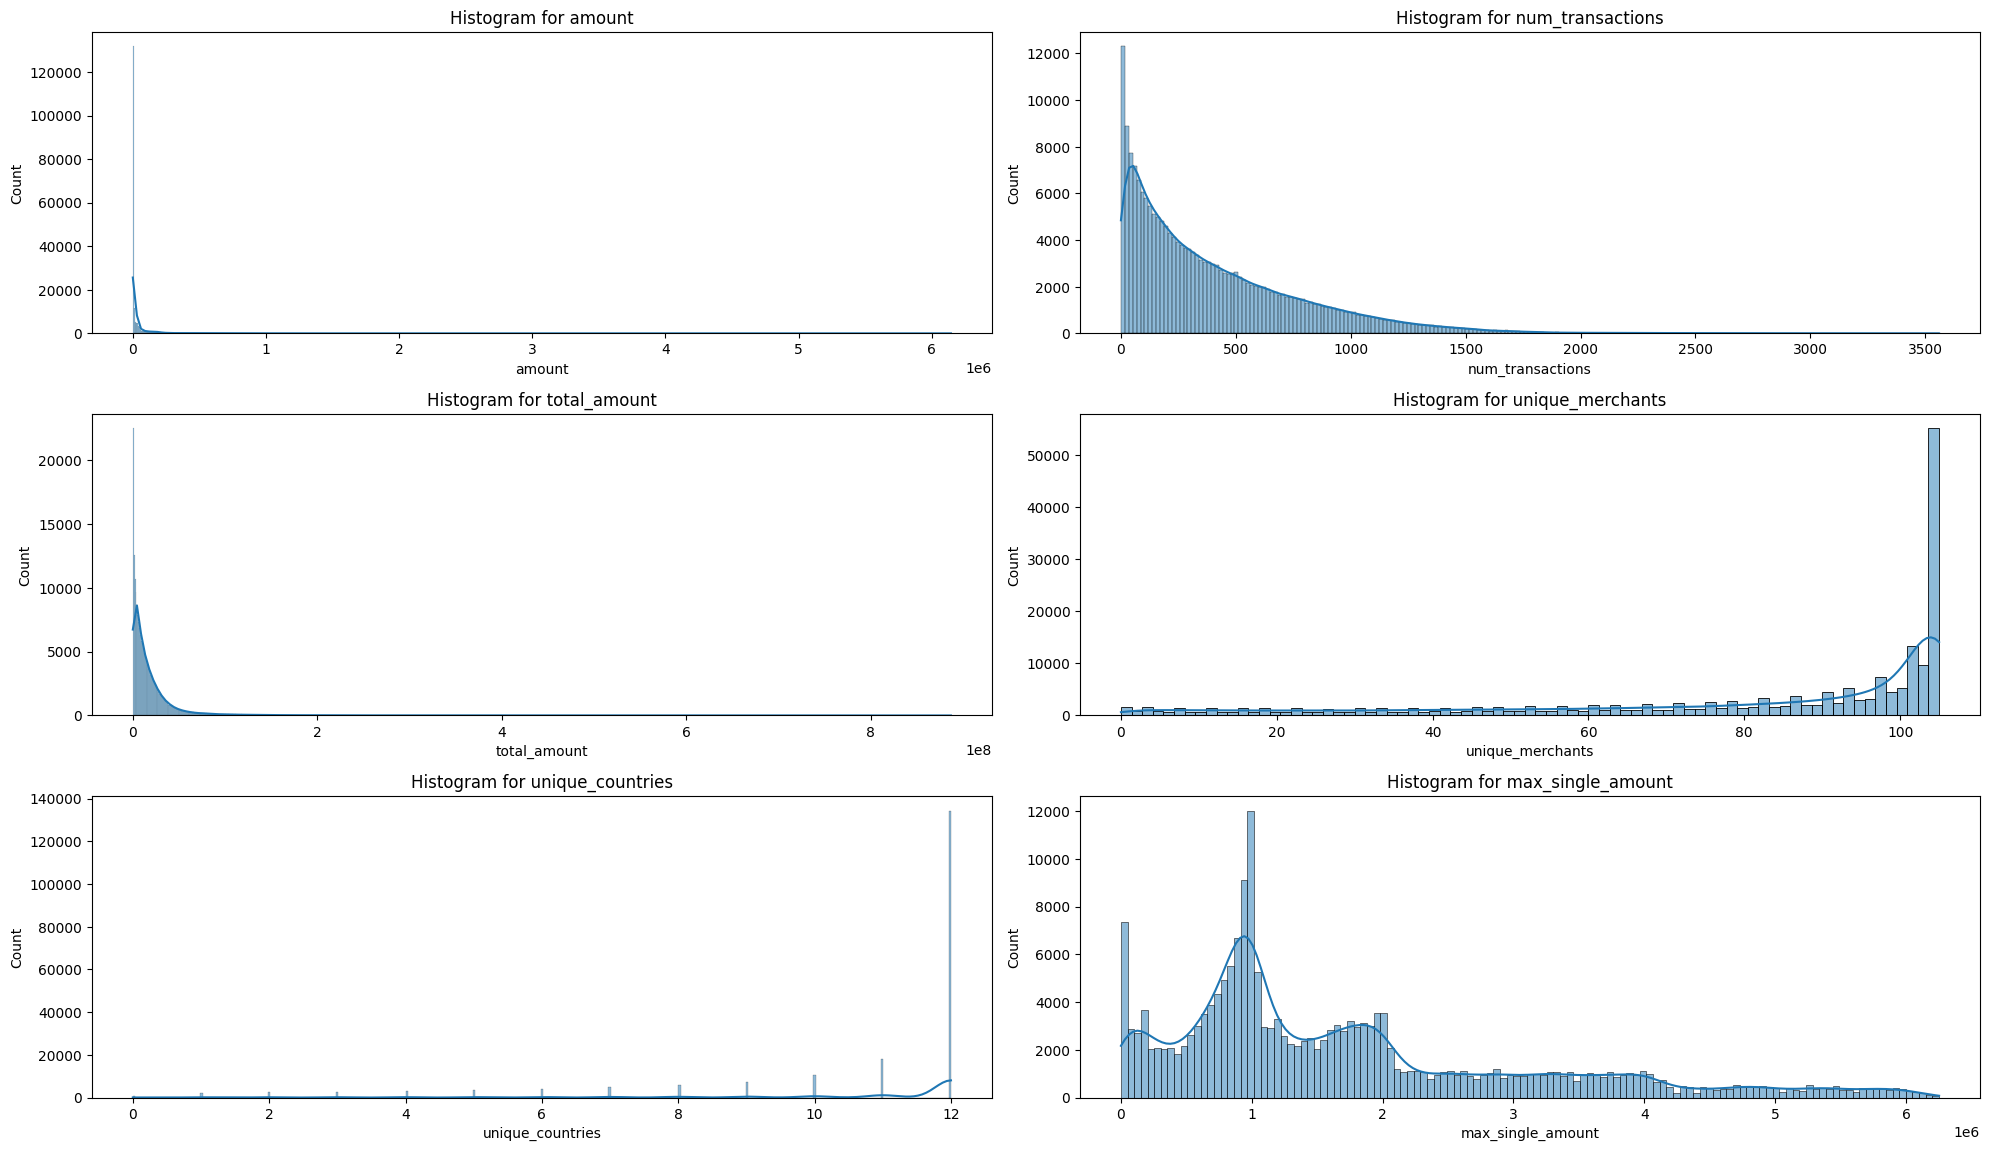

In [26]:
# Distributions of the numeric features
numerical_cols = eda_plot.select_dtypes(include=['int', 'float']).columns
numerical_cols = numerical_cols.drop(
    ['card_present', 'distance_from_home', 'high_risk_merchant', 'weekend_transaction', 'is_fraud',
     'year', 'month', 'day', 'hour', 'minute', 'second', 'microsecond'], errors='ignore')

ncol = 2
nrow = len(numerical_cols) // ncol + 1
fig, axes = plt.subplots(nrow, ncol, figsize=(20, 15))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(data=eda_plot, x=col, ax=axes[i], kde=True)
    axes[i].set_title(f'Histogram for {col}')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

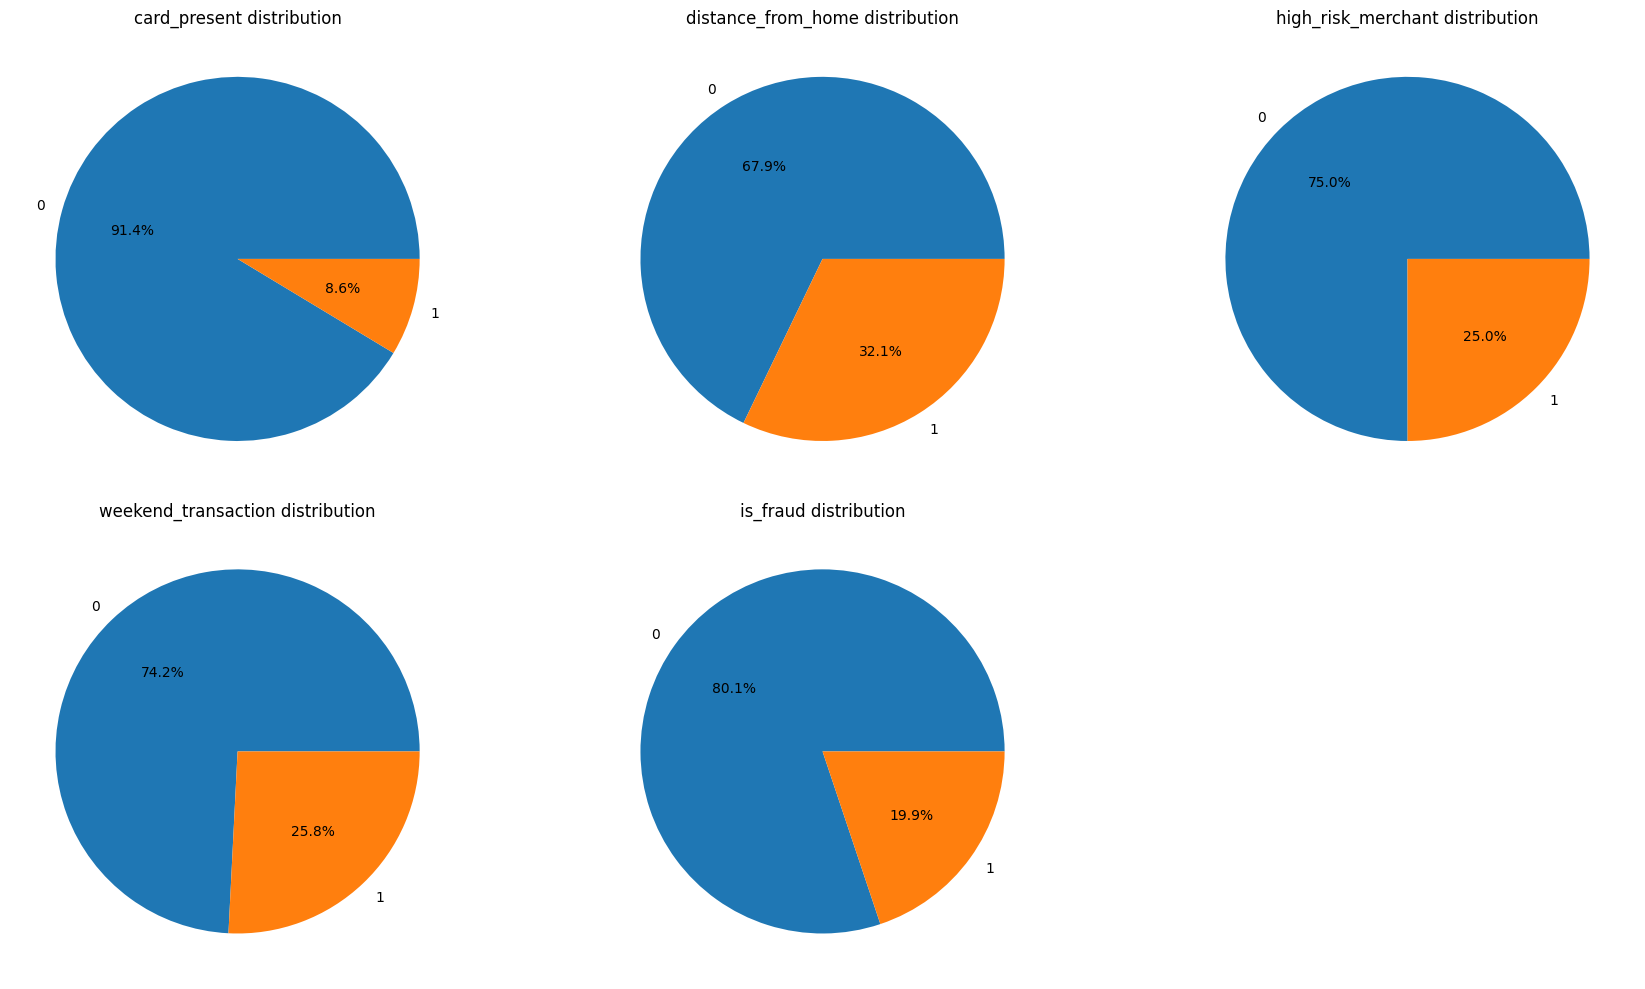

In [27]:
# Balance of the binary columns
binary_cols = ['card_present', 'distance_from_home', 'high_risk_merchant', 'weekend_transaction', 'is_fraud']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    eda_plot[col].value_counts(normalize=True).plot.pie(ax=axes[i], autopct='%1.1f%%')
    axes[i].set_title(f'{col} distribution')
    axes[i].set_ylabel('')
for j in range(len(binary_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

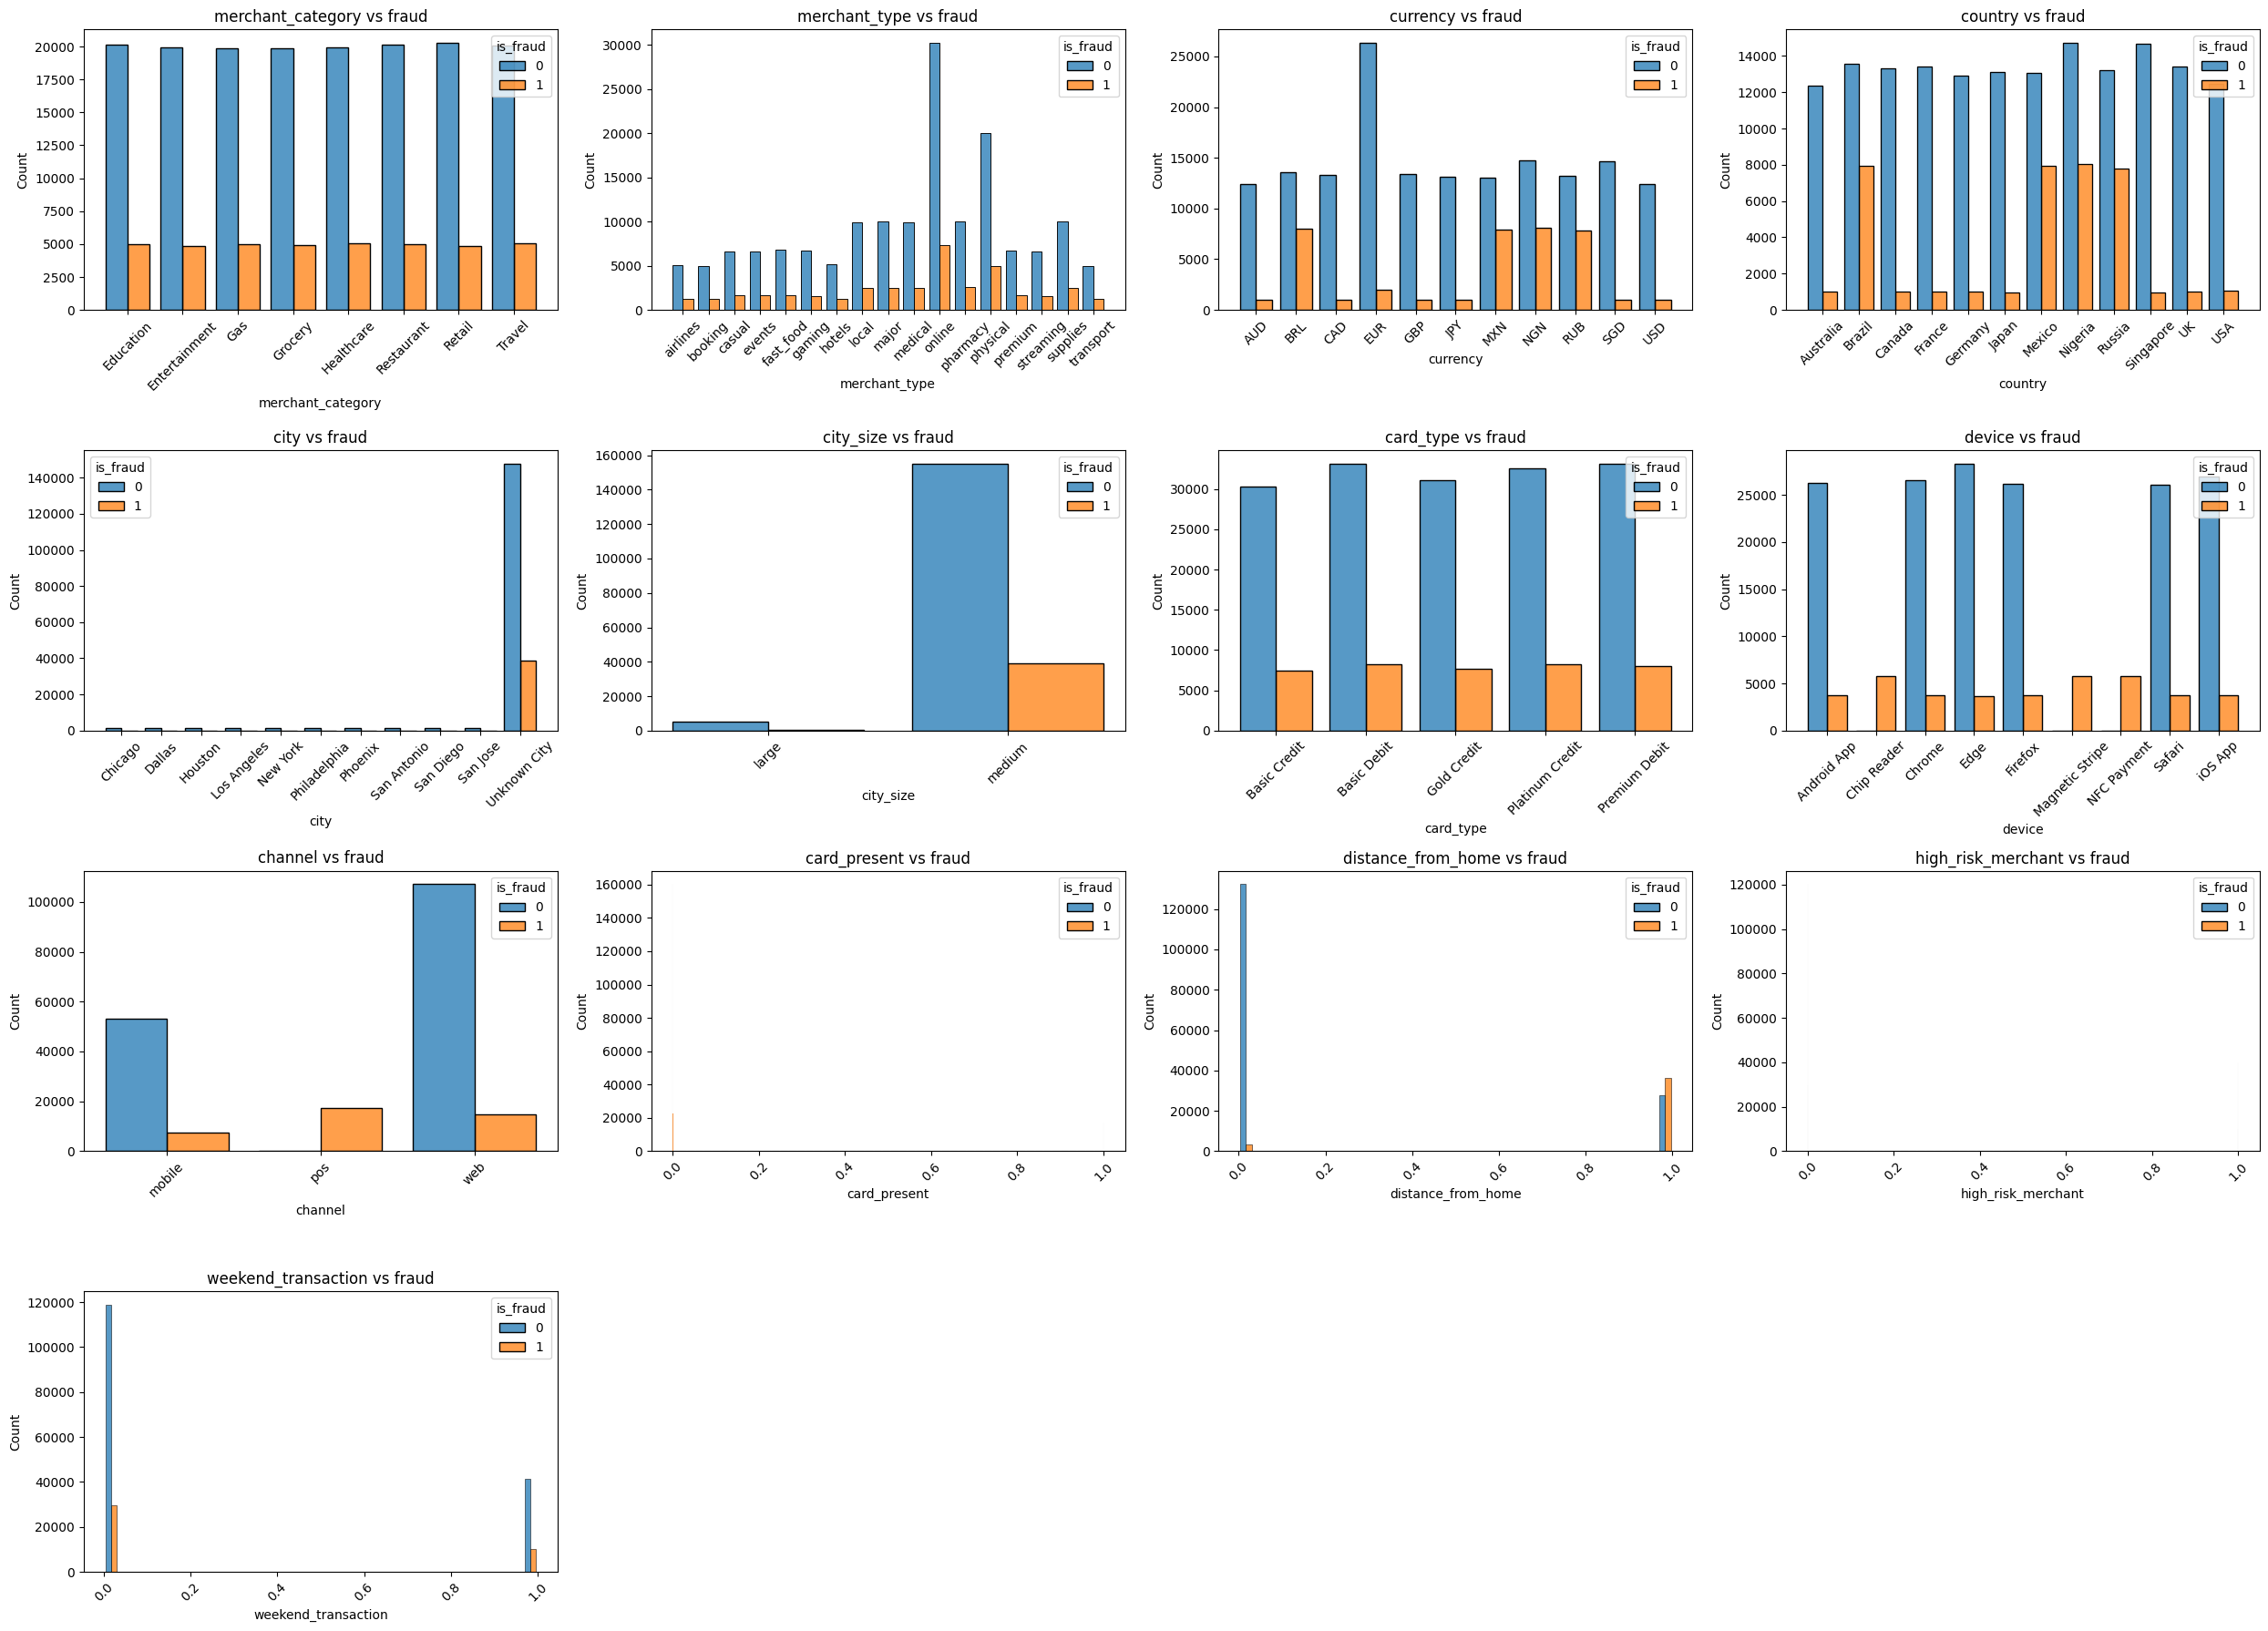

In [28]:
# Categorical features vs fraud status
categorical_cols = list(eda_plot.select_dtypes(['object', 'category']).columns)
categorical_cols += ['card_present', 'distance_from_home', 'high_risk_merchant', 'weekend_transaction']
if 'merchant' in categorical_cols:
    categorical_cols.remove('merchant')

ncol = 4
nrow = len(categorical_cols) // ncol + 1
fig, axes = plt.subplots(nrow, ncol, figsize=(25, 18))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.histplot(data=eda_plot, x=col, hue='is_fraud', multiple='dodge', shrink=0.8, ax=axes[i])
    axes[i].set_title(f'{col} vs fraud')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

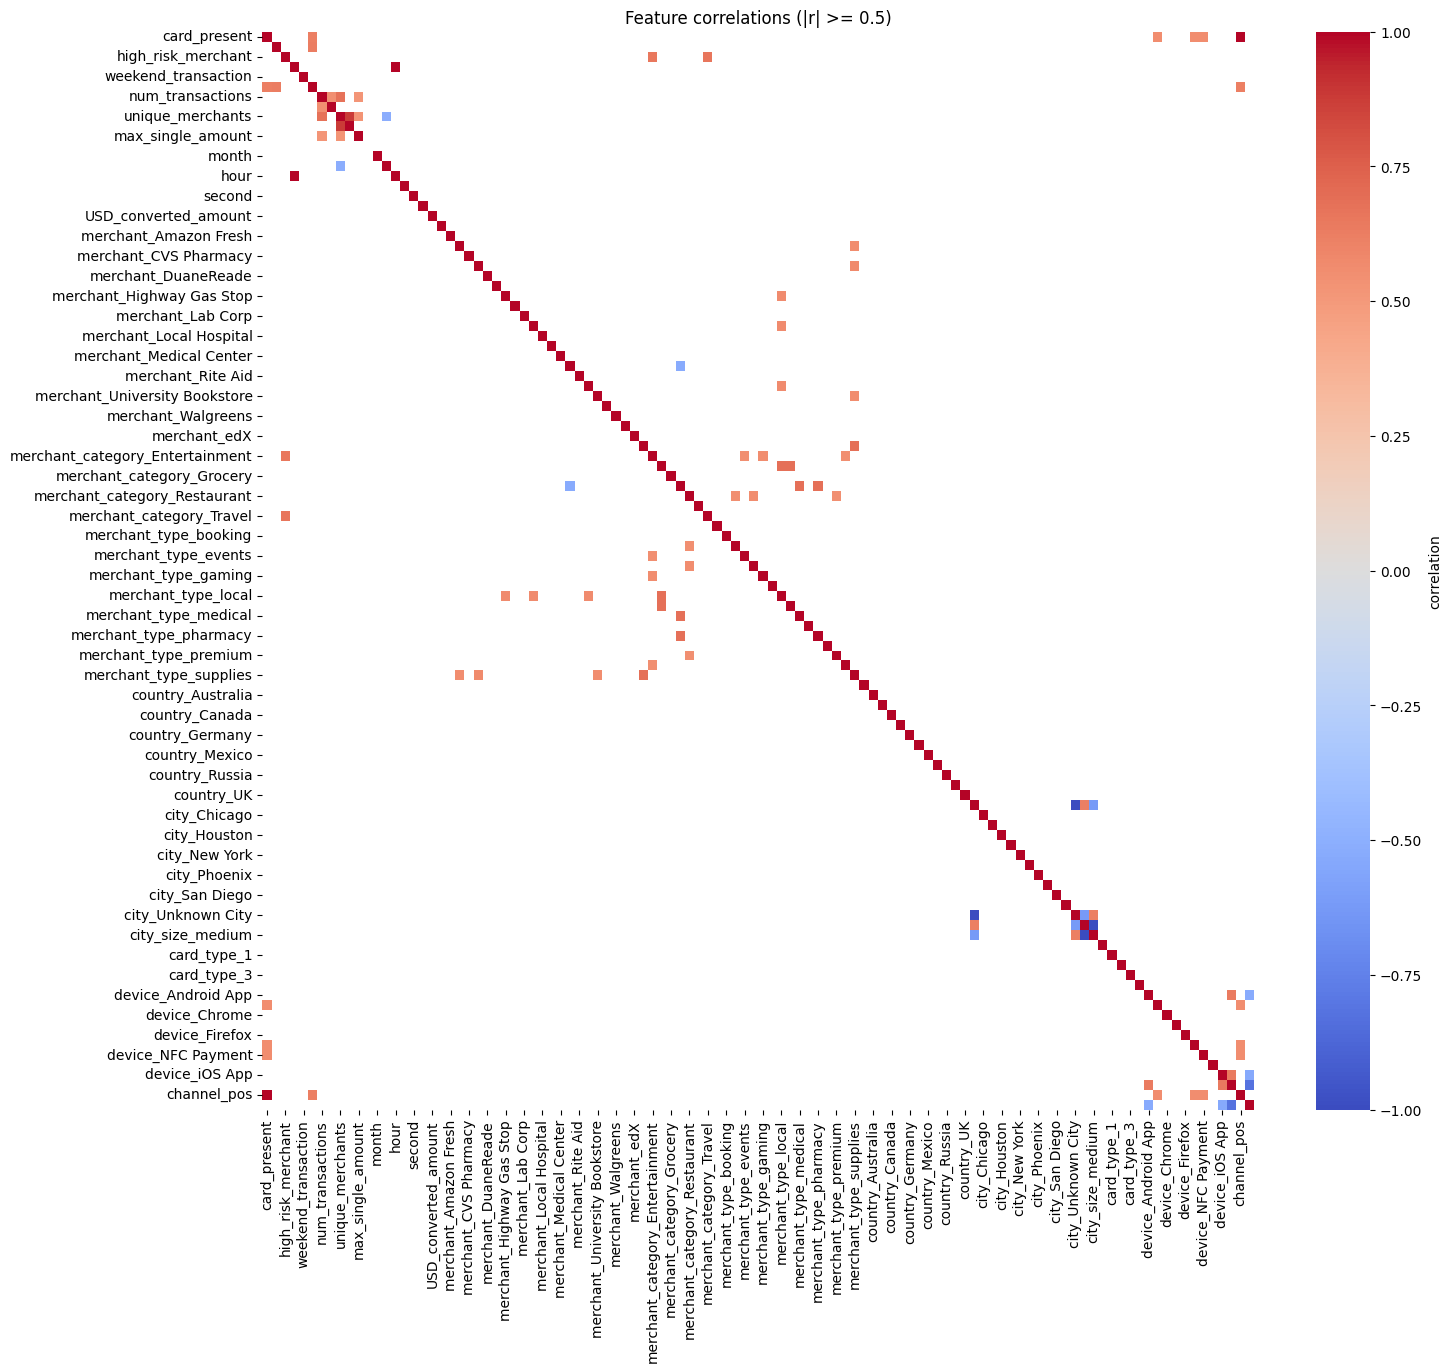

In [29]:
# Correlation heatmap (computed on the feature-engineered render sample)
fe_sample = feature_engineer(eda_plot)
corr = fe_sample.corr()
mask = corr[abs(corr) >= 0.5].isnull()
plt.figure(figsize=(16, 14))
sns.heatmap(corr[abs(corr) >= 0.5], vmin=-1, vmax=1, center=0, cmap='coolwarm',
            mask=mask, cbar_kws={'label': 'correlation'})
plt.title('Feature correlations (|r| >= 0.5)')
plt.show()

# Modelling - XGBoost on GPU

A single `XGBClassifier` is trained, configured for the Kaggle **T4** GPU via `device='cuda'`
(`tree_method='hist'`). XGBoost uses a single GPU per process; one T4 is more than enough here.
To use **both** T4s you would need `xgboost.dask` with a `LocalCUDACluster` - omitted for simplicity.

Because the test set keeps its real class ratio, we report **PR-AUC (average precision)** alongside
ROC-AUC: under extreme imbalance (the realistic 0.75% regime) ROC-AUC is over-optimistic, while
PR-AUC reflects performance on the rare positive class.

In [30]:
def evaluate_xgboost(X_train, X_test, y_train, y_test, title):
    model = XGBClassifier(
        n_estimators=100,
        tree_method='hist',
        device='cuda',          # Kaggle T4 GPU. Use device='cpu' (or 'gpu_hist' on XGBoost<2.0) otherwise.
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f'===== XGBoost - {title} =====')
    print(classification_report(y_test, y_pred, digits=4))
    metrics = {
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba),
    }
    for k, v in metrics.items():
        print(f'{k:10s}: {v:.4f}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, color='darkorange', label=f"ROC (AUC={metrics['ROC-AUC']:.3f})")
    axes[0].plot([0, 1], [0, 1], '--', color='navy')
    axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC curve'); axes[0].legend(loc='lower right')
    # Precision-Recall curve
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[1].plot(rec, prec, color='purple', label=f"PR (AP={metrics['PR-AUC']:.3f})")
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall curve'); axes[1].legend(loc='upper right')
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot(ax=axes[2], colorbar=False)
    axes[2].set_title('Confusion matrix')
    plt.suptitle(f'XGBoost - {title}')
    plt.tight_layout()
    plt.show()
    return metrics

In [31]:
def run_experiment(data_raw, title):
    clean = feature_engineer(preprocess(data_raw))
    X_train, X_test, y_train, y_test, feats = prepare_train_test(clean)
    del clean
    gc.collect()
    print(f'[{title}] features ({len(feats)}): {feats}')
    print(f'[{title}] train after ROS: {X_train.shape} | test: {X_test.shape} | '
          f'test fraud rate: {y_test.mean() * 100:.3f}%\n')
    return evaluate_xgboost(X_train, X_test, y_train, y_test, title)

## Experiment 1 - untouched dataset

The dataset as provided, run end-to-end through the pipeline.

[Untouched (full dataset)] features (20): ['distance_from_home', 'card_present', 'channel_pos', 'device_Magnetic Stripe', 'device_Chip Reader', 'device_NFC Payment', 'hour', 'transaction_hour', 'channel_web', 'USD_converted_amount', 'is_bank_operating', 'country_Mexico', 'country_Russia', 'country_Brazil', 'country_Nigeria', 'channel_mobile', 'country_Singapore', 'device_Edge', 'country_France', 'country_Japan']
[Untouched (full dataset)] train after ROS: (9582474, 20) | test: (1496754, 20) | test fraud rate: 19.973%



/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [08:47:00] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


===== XGBoost - Untouched (full dataset) =====
              precision    recall  f1-score   support

           0     0.9843    0.9519    0.9678   1197810
           1     0.8298    0.9391    0.8811    298944

    accuracy                         0.9494   1496754
   macro avg     0.9070    0.9455    0.9244   1496754
weighted avg     0.9534    0.9494    0.9505   1496754

Recall    : 0.9391
Precision : 0.8298
F1-Score  : 0.8811
ROC-AUC   : 0.9884
PR-AUC    : 0.9686


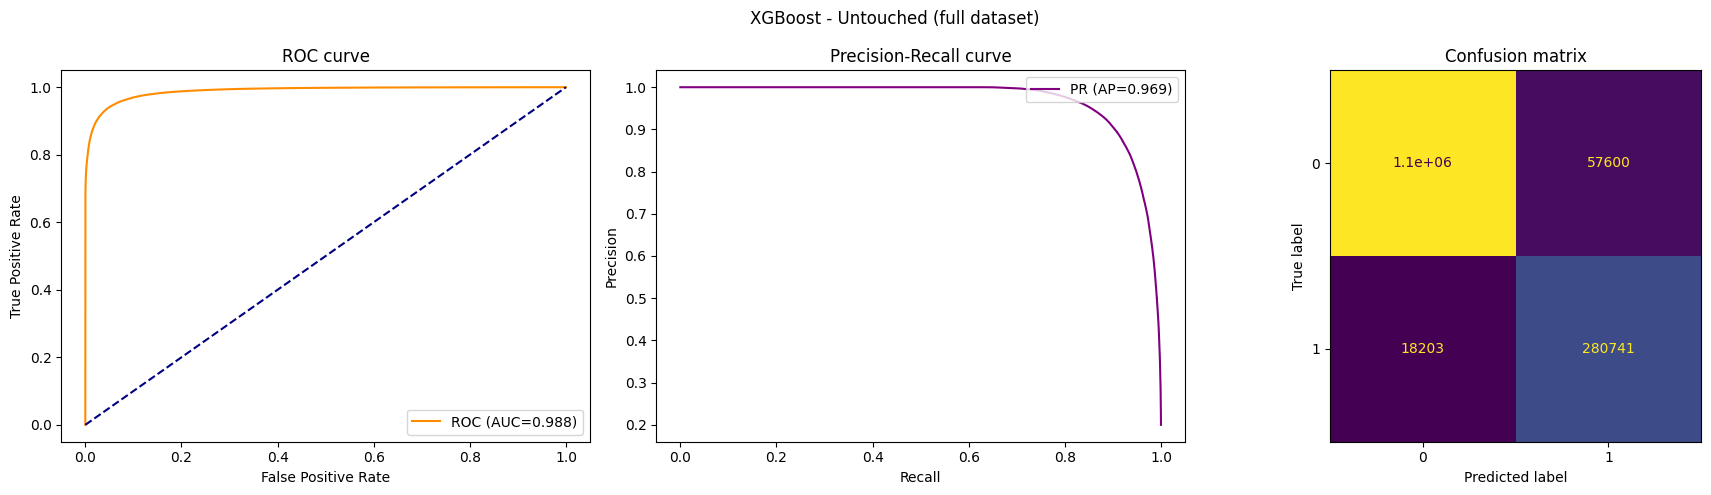

In [32]:
results_untouched = run_experiment(df_untouched, 'Untouched (full dataset)')

## Experiment 2 - realistic ratio (99.25 : 0.75)

The same pipeline on the realistically down-sampled data.

[Realistic (99.25 : 0.75)] features (20): ['card_present', 'channel_pos', 'device_NFC Payment', 'device_Chip Reader', 'device_Magnetic Stripe', 'distance_from_home', 'USD_converted_amount', 'transaction_hour', 'hour', 'channel_web', 'country_Russia', 'is_bank_operating', 'country_Mexico', 'country_Brazil', 'country_Nigeria', 'channel_mobile', 'country_Singapore', 'country_UK', 'country_France', 'country_Canada']
[Realistic (99.25 : 0.75)] train after ROS: (9582474, 20) | test: (1206861, 20) | test fraud rate: 0.750%

===== XGBoost - Realistic (99.25 : 0.75) =====
              precision    recall  f1-score   support

           0     0.9995    0.9536    0.9760   1197810
           1     0.1322    0.9355    0.2317      9051

    accuracy                         0.9535   1206861
   macro avg     0.5659    0.9445    0.6039   1206861
weighted avg     0.9930    0.9535    0.9704   1206861

Recall    : 0.9355
Precision : 0.1322
F1-Score  : 0.2317
ROC-AUC   : 0.9878
PR-AUC    : 0.8166


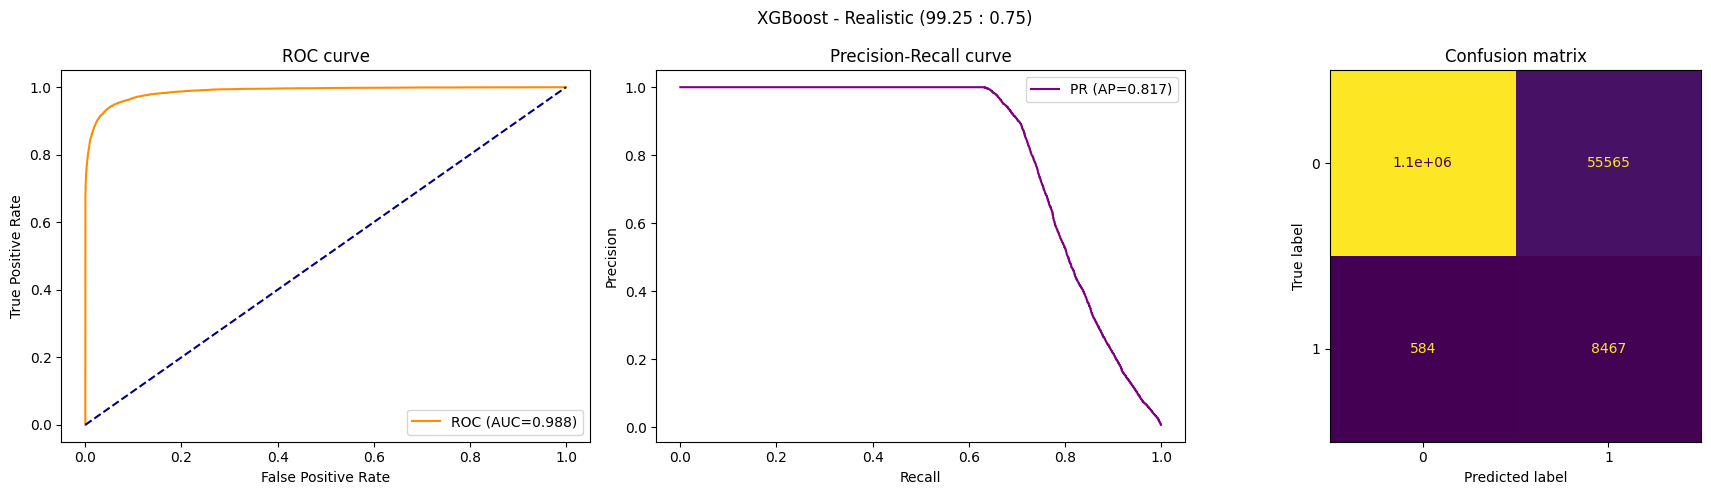

In [33]:
results_realistic = run_experiment(df_realistic, 'Realistic (99.25 : 0.75)')

# Comparison summary

The two XGBoost runs side by side. The training set is balanced (RandomOverSampler) in both cases,
so the difference comes from the **test-set class ratio**: the realistic regime is evaluated against a
~0.75% fraud base rate.

In [34]:
comparison = pd.DataFrame({
    'Untouched (full)': results_untouched,
    'Realistic (99.25 : 0.75)': results_realistic,
}).T[['Recall', 'Precision', 'F1-Score', 'ROC-AUC', 'PR-AUC']].round(4)
comparison

,Recall,Precision,F1-Score,ROC-AUC,PR-AUC
Untouched (full),0.9391,0.8298,0.8811,0.9884,0.9686
Realistic (99.25 : 0.75),0.9355,0.1322,0.2317,0.9878,0.8166


# Notes & expected reading

- **Same pipeline, two regimes, one model.** Only the data scope (full vs realistic ratio) and the
  model (XGBoost) differ from v1.
- **Why PR-AUC matters here.** On the realistic 0.75% test set, expect **ROC-AUC to stay high** while
  **precision / F1 / PR-AUC drop**: at a 0.75% base rate even a small false-positive rate produces many
  more false alarms than true frauds. PR-AUC is the honest headline metric for the realistic regime.
- **Recall vs precision trade-off.** Oversampling the training set tends to preserve recall (catching
  fraud) at the cost of precision when deployed against realistic prevalence - exactly the effect this
  experiment is designed to surface.
- **Execution.** This notebook is intended to be run on **Kaggle with the T4 x2 accelerator**; it is
  shipped **without outputs** (run "Save & Run All" on Kaggle to populate them).